#Phân tích Dữ liệu Dự báo: Phát hiện Giao dịch Bất thường trên Bitcoin Network
**Dataset:** Elliptic Data Set  
**Mục tiêu:** Áp dụng quy trình Data Exploration, Data Preparation (Missing Values, Outliers, Imbalance) và huấn luyện mô hình phân loại chuỗi thời gian.

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np

# 1. Tải và lấy đường dẫn dataset
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
classes_path, features_path = None, None

for root, _, files in os.walk(path):
    if "elliptic_txs_classes.csv" in files:
        classes_path = os.path.join(root, "elliptic_txs_classes.csv")
    if "elliptic_txs_features.csv" in files:
        features_path = os.path.join(root, "elliptic_txs_features.csv")

# 2. Đọc file classes
df_classes = pd.read_csv(classes_path)

# 3. Đọc file features (file gốc không có header nên gán header=None)
df_features = pd.read_csv(features_path, header=None)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
# 1. Kích thước dòng x cột
print(f"Kích thước DataFrame: {df.shape[0]:,} dòng, {df.shape[1]} cột")

# 2. Dung lượng RAM DataFrame đang chiếm dụng
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Bộ nhớ tiêu tốn: {memory_mb:.2f} MB")

# 3. Phân loại các kiểu dữ liệu hiện có
print("\nSố lượng cột theo từng kiểu dữ liệu:")
print(df.dtypes.value_counts())

Kích thước DataFrame: 203,769 dòng, 168 cột
Bộ nhớ tiêu tốn: 270.24 MB

Số lượng cột theo từng kiểu dữ liệu:
float64    165
int64        2
object       1
Name: count, dtype: int64


In [ ]:
# 1. Tổng số lượng ô khuyết (NaN) trên toàn bộ bảng
total_nans = df.isnull().sum().sum()
print(f"Tổng số giá trị NaN: {total_nans}")

# 2. Kiểm tra tính duy nhất của khóa chính (txId)
total_rows = len(df)
unique_txids = df['txId'].nunique()
print(f"Tổng số dòng: {total_rows:,} | Số txId duy nhất: {unique_txids:,}")
print(f"-> Khóa chính txId có bị trùng lặp không: {'Có' if total_rows != unique_txids else 'Không'}")

# 3. Kiểm tra trùng lặp toàn bộ dòng (Duplicate rows)
print(f"Số dòng trùng lặp tuyệt đối: {df.duplicated().sum()}")

Tổng số giá trị NaN: 0
Tổng số dòng: 203,769 | Số txId duy nhất: 203,769
-> Khóa chính txId có bị trùng lặp không: Không
Số dòng trùng lặp tuyệt đối: 0


In [ ]:
# 1. Số lượng tuyệt đối và tỷ lệ phần trăm của từng nhãn
class_counts = df['class'].value_counts()
class_pct = df['class'].value_counts(normalize=True) * 100

summary_class = pd.DataFrame({'Số lượng': class_counts, 'Tỷ lệ (%)': class_pct})
display(summary_class)

# 2. Tính tỷ lệ mất cân bằng chỉ trên tập dữ liệu ĐÃ CÓ NHÃN (1 vs 2)
labeled_only = df[df['class'].isin(['1', '2'])]
ratio = (labeled_only['class'] == '2').sum() / (labeled_only['class'] == '1').sum()
print(f"\nTrong tập có nhãn:")
print(f"- Số ca Hợp pháp (2) gấp {ratio:.2f} lần số ca Bất hợp pháp (1).")

,Số lượng,Tỷ lệ (%)
class,,
unknown,157205,77.148634
2,42019,20.620899
1,4545,2.230467



Trong tập có nhãn:
- Số ca Hợp pháp (2) gấp 9.25 lần số ca Bất hợp pháp (1).


In [ ]:
# 1. Kiểm tra phạm vi các bước thời gian
print(f"Phạm vi time_step: từ {df['time_step'].min()} đến {df['time_step'].max()} (Tổng {df['time_step'].nunique()} bước)")

# 2. Thống kê số lượng từng loại nhãn theo từng time_step (Cross-tabulation)
step_distribution = pd.crosstab(df['time_step'], df['class'])
print("\n5 time-step đầu tiên:")
display(step_distribution.head())

# 3. Tìm các time_step có số lượng giao dịch bất hợp pháp (nhãn 1) đột biến
illicit_by_step = step_distribution['1'].sort_values(ascending=False)
print("\nTop 5 time-step có nhiều giao dịch bất hợp pháp nhất:")
display(illicit_by_step.head())

Phạm vi time_step: từ 1 đến 49 (Tổng 49 bước)

5 time-step đầu tiên:


class,1,2,unknown
time_step,,,
1,17,2130,5733
2,18,1099,3427
3,11,1268,5342
4,30,1410,4253
5,8,1874,4921



Top 5 time-step có nhiều giao dịch bất hợp pháp nhất:


,1
time_step,
32,342
29,329
13,291
20,260
9,248


In [ ]:
# 1. Lọc ra danh sách cột đặc trưng
local_cols = [c for c in df.columns if c.startswith('local_feat_')]
agg_cols = [c for c in df.columns if c.startswith('agg_feat_')]
print(f"Số cột Local Features: {len(local_cols)}")
print(f"Số cột Aggregated Features: {len(agg_cols)}")

# 2. Thống kê mô tả (Mean, Std, Min, 25%, 50%, 75%, Max) của một vài cột tiêu biểu
sample_cols = ['local_feat_1', 'local_feat_2', 'agg_feat_1', 'agg_feat_2']
display(df[sample_cols].describe().T)

# 3. Kiểm tra nhanh sự tồn tại của Outlier (Max cách rất xa phân vị 75%)
for col in sample_cols:
    q75 = df[col].quantile(0.75)
    max_val = df[col].max()
    print(f"Cột {col:12s} -> Q3: {q75:.4f} | Max: {max_val:.4f} | Tỷ lệ Max/Q3: {max_val/q75 if q75 != 0 else np.nan:.1f}")

Số cột Local Features: 93
Số cột Aggregated Features: 72


,count,mean,std,min,25%,50%,75%,max
local_feat_1,203769.0,2.454849e-17,1.000002,-0.172983,-0.172532,-0.169204,-0.131855,71.681966
local_feat_2,203769.0,-7.531922e-18,1.000002,-0.210553,-0.180327,-0.132897,-0.055242,73.595052
agg_feat_1,203769.0,4.017025e-17,1.000002,-0.171099,-0.170638,-0.166426,-0.118200,48.939956
agg_feat_2,203769.0,2.064305e-17,1.000002,-0.203105,-0.201890,-0.193195,-0.123954,127.113709


Cột local_feat_1 -> Q3: -0.1319 | Max: 71.6820 | Tỷ lệ Max/Q3: -543.6
Cột local_feat_2 -> Q3: -0.0552 | Max: 73.5951 | Tỷ lệ Max/Q3: -1332.2
Cột agg_feat_1   -> Q3: -0.1182 | Max: 48.9400 | Tỷ lệ Max/Q3: -414.0
Cột agg_feat_2   -> Q3: -0.1240 | Max: 127.1137 | Tỷ lệ Max/Q3: -1025.5


In [ ]:
# 1. Đếm tổng số giá trị bị thiếu (NaN/None) trên từng cột
mis_val = df.isnull().sum()

# 2. Tính tỷ lệ phần trăm bị khuyết của từng cột so với tổng số dòng
mis_val_percent = 100 * df.isnull().sum() / len(df)

# 3. Ghép 2 Series (số lượng và tỷ lệ) lại thành một DataFrame theo chiều dọc (axis=1 là ghép cột)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

# 4. Đổi tên cột mặc định (0 và 1) thành tên có ngữ nghĩa
mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'}
)

# 5. Lọc và sắp xếp:
# - mis_val_table_ren_columns.iloc[:, 1] != 0: Chỉ giữ lại các cột THỰC SỰ có khuyết (bỏ qua cột đầy đủ 100%)
# - sort_values(..., ascending=False): Sắp xếp cột nào bị khuyết nhiều nhất lên đầu bảng
# - .round(1): Làm tròn số thập phân đến 1 chữ số
mis_val_table_ren_columns = mis_val_table_ren_columns[
    mis_val_table_ren_columns.iloc[:,1] != 0
].sort_values('% of Total Values', ascending=False).round(1)

# 6. In thông báo tóm tắt ra màn hình console
print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
       "There are " + str(mis_val_table_ren_columns.shape[0]) +
       " columns that have missing values.")

# 7. Trả về DataFrame báo cáo kết quả
print(mis_val_table_ren_columns)

Your selected dataframe has 168 columns.
There are 0 columns that have missing values.
Empty DataFrame
Columns: [Missing Values, % of Total Values]
Index: []


In [ ]:
# Lọc chỉ lấy các giao dịch đã biết nhãn (1: Illicit, 2: Licit)
df_labeled = df[df['class'].isin(['1', '2'])].copy()

# Ánh xạ nhãn: 1 -> 1 (Gian lận), 2 -> 0 (Hợp pháp)
df_labeled['target'] = df_labeled['class'].map({'1': 1, '2': 0}).astype(int)

# Tách danh sách cột đặc trưng (bỏ txId, time_step, class, target)
feature_cols = [c for c in df_labeled.columns if c.startswith(('local_', 'agg_'))]

print(f"Tổng số mẫu có nhãn: {df_labeled.shape[0]:,}")
print(f"Tỷ lệ gian lận thực tế: {df_labeled['target'].mean() * 100:.2f}%")

Tổng số mẫu có nhãn: 46,564
Tỷ lệ gian lận thực tế: 9.76%


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(df_labeled[feature_cols])

selected_features = [col for col, keep in zip(feature_cols, selector.get_support()) if keep]
print(f"Số cột ban đầu: {len(feature_cols)}")
print(f"Số cột giữ lại sau khi lọc: {len(selected_features)}")

Số cột ban đầu: 165
Số cột giữ lại sau khi lọc: 164


Using Colab cache for faster access to the 'elliptic-data-set' dataset.


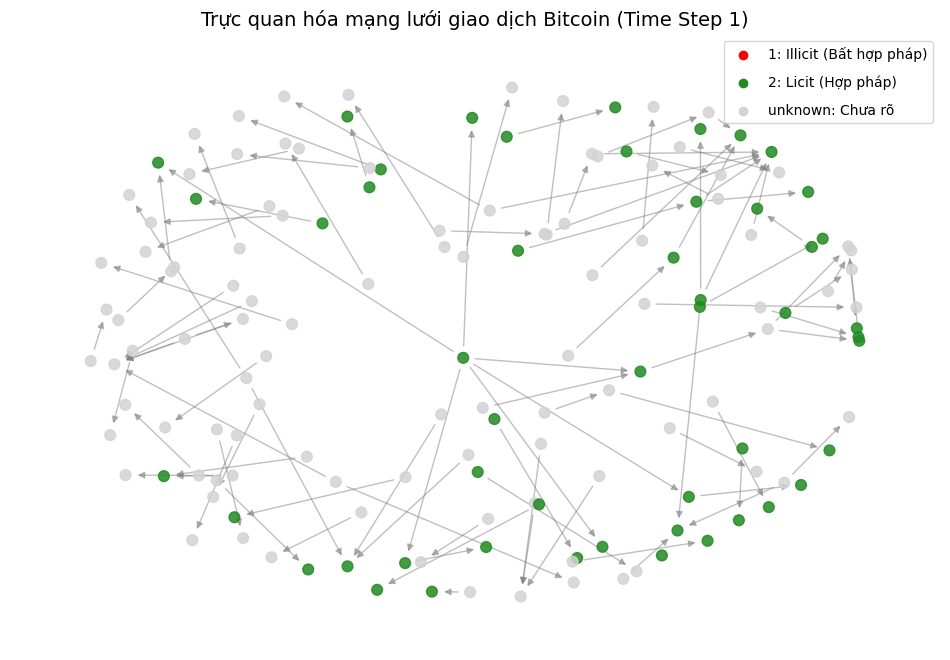

In [ ]:
import os
import kagglehub
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Định vị đường dẫn các file
path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
classes_path = None
features_path = None
edgelist_path = None

for root, dirs, files in os.walk(path):
    if "elliptic_txs_classes.csv" in files:
        classes_path = os.path.join(root, "elliptic_txs_classes.csv")
    if "elliptic_txs_features.csv" in files:
        features_path = os.path.join(root, "elliptic_txs_features.csv")
    if "elliptic_txs_edgelist.csv" in files:
        edgelist_path = os.path.join(root, "elliptic_txs_edgelist.csv")

# 2. Đọc dữ liệu
df_classes = pd.read_csv(classes_path)
df_edgelist = pd.read_csv(edgelist_path)

# Đọc 2 cột đầu của features để lấy txId và time_step (tiết kiệm RAM)
df_features_time = pd.read_csv(features_path, header=None, usecols=[0, 1])
df_features_time.columns = ['txId', 'time_step']

# 3. Lọc lấy các giao dịch ở Time Step 1
nodes_step1 = df_features_time[df_features_time['time_step'] == 1]['txId'].values

# Lọc classes và edges chỉ thuộc Step 1
df_classes_step1 = df_classes[df_classes['txId'].isin(nodes_step1)]
df_edges_step1 = df_edgelist[
    df_edgelist['txId1'].isin(nodes_step1) & df_edgelist['txId2'].isin(nodes_step1)
]

# 4. Xây dựng đồ thị có hướng bằng NetworkX
G = nx.from_pandas_edgelist(
    df_edges_step1, source='txId1', target='txId2', create_using=nx.DiGraph()
)

# Chỉ lấy đồ thị con có cạnh kết nối (loại bỏ node cô lập để đồ thị rõ ràng)
connected_nodes = [node for node in G.nodes() if G.degree(node) > 0]
subgraph = G.subgraph(connected_nodes[:150]) # Lấy 150 nodes đầu tiên để vẽ trực quan

# 5. Gán màu theo nhãn: Đỏ (Illicit), Xanh lá (Licit), Xám (Unknown)
label_dict = dict(zip(df_classes_step1['txId'], df_classes_step1['class']))
color_map = []

for node in subgraph.nodes():
    label = str(label_dict.get(node, 'unknown'))
    if label == '1':
        color_map.append('red')        # Bất hợp pháp
    elif label == '2':
        color_map.append('forestgreen') # Hợp pháp
    else:
        color_map.append('lightgray')   # Chưa xác định

# 6. Vẽ đồ thị
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(subgraph, seed=42, k=0.3)
nx.draw_networkx_nodes(subgraph, pos, node_size=60, node_color=color_map, alpha=0.85)
nx.draw_networkx_edges(subgraph, pos, arrows=True, arrowsize=10, edge_color='gray', alpha=0.5)

# Thêm chú thích
plt.title("Trực quan hóa mạng lưới giao dịch Bitcoin (Time Step 1)", fontsize=14)
plt.scatter([], [], c='red', label='1: Illicit (Bất hợp pháp)')
plt.scatter([], [], c='forestgreen', label='2: Licit (Hợp pháp)')
plt.scatter([], [], c='lightgray', label='unknown: Chưa rõ')
plt.legend(scatterpoints=1, frameon=True, labelspacing=1, loc='upper right')
plt.axis('off')
plt.show()

In [ ]:

# 1. Lọc nhãn đã biết và chuyển đổi nhị phân: 1 (Illicit), 0 (Licit)
df_labeled = df[df['class'].isin(['1', '2'])].copy()
df_labeled['target'] = df_labeled['class'].map({'1': 1, '2': 0}).astype(int)

# 2. Lấy danh sách 165 cột đặc trưng số
feature_cols = [c for c in df_labeled.columns if c.startswith(('local_', 'agg_'))]

# 3. Chia tách theo trục thời gian (Time-step 1-34: Train, 35-49: Test)
train_mask = df_labeled['time_step'] <= 34
test_mask = df_labeled['time_step'] > 34

X_train = df_labeled.loc[train_mask, feature_cols].copy()
y_train = df_labeled.loc[train_mask, 'target'].copy()

X_test = df_labeled.loc[test_mask, feature_cols].copy()
y_test = df_labeled.loc[test_mask, 'target'].copy()

print(f"Khởi tạo tập Train: {X_train.shape[0]:,} dòng | Tập Test: {X_test.shape[0]:,} dòng")

Khởi tạo tập Train: 29,894 dòng | Tập Test: 16,670 dòng


In [ ]:
from sklearn.feature_selection import VarianceThreshold

# 1. Khởi tạo bộ lọc với ngưỡng phương sai tối thiểu 0.01
selector = VarianceThreshold(threshold=0.01)

# 2. Học tiêu chí trên Train và biến đổi cả Train lẫn Test
X_train_selected = selector.fit_transform(X_train)
X_test_selected = selector.transform(X_test)

# Lấy lại danh sách tên cột đạt chuẩn
selected_features = [col for col, keep in zip(feature_cols, selector.get_support()) if keep]

# Chuyển đổi lại thành DataFrame để tiện xử lý tiếp
X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

print(f"Số lượng đặc trưng giữ lại: {len(selected_features)}/{len(feature_cols)}")

Số lượng đặc trưng giữ lại: 164/165
